In [6]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter as fsf
from plots.mpltoolkit import mpl_loc, fancy_legend, named_colors, load_style_sheet, negative_log
import numpy as np
import vice
import sys
import os
sys.path.insert(0, "..")
from src.utils import subsample_stars, get_velocity_evolution, get_velocity_profile
load_style_sheet("papers")
print(sys.version_info[:])

(3, 12, 3, 'final', 0)


In [14]:
# output = vice.output("../outputs/expifr/base")
# output = vice.output("../outputs/expifr-GSE/initial")
output = vice.output("../outputs/expifr-GSE/initial2")
extra = np.genfromtxt("%s_analogdata.out" % (output.name))
output.stars["absz"] = [abs(_) for _ in extra[:,-1][:output.stars.size[0]]]

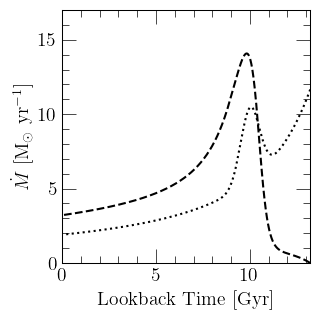

In [15]:
fig = plt.figure(figsize = (3.3, 3.3))
ax = fig.add_subplot(111)
ax.set_xlabel(r"Lookback Time [Gyr]")
ax.set_ylabel(r"$\dot{M}$ [M$_\odot$ yr$^{-1}$]")
ax.set_xlim([0, 13.2])
ax.set_ylim([0, 17])

def plot_ifr_sfr(ax, output, **kwargs):
    lookback = output.zones["zone0"].history["lookback"]
    ifr = len(lookback) * [0.]
    sfr = len(lookback) * [0.]
    for i in range(len(lookback)):
        ifr[i] += sum([output.zones["zone%d" % (_)].history["ifr"][i] for _ in range(len(output.zones.keys()))])
        sfr[i] += sum([output.zones["zone%d" % (_)].history["sfr"][i] for _ in range(len(output.zones.keys()))])
    ifr = []
    sfr = []
    for i in range(len(lookback)):
        ifr.append(0)
        sfr.append(0)
        for j in range(len(output.zones.keys())):
            ifr[-1] += output.zones["zone%d" % (j)].history["ifr"][i]
            sfr[-1] += output.zones["zone%d" % (j)].history["sfr"][i]
    ax.plot(lookback, ifr, linestyle = ":", **kwargs)
    ax.plot(lookback, sfr, linestyle = "--", **kwargs)

plot_ifr_sfr(ax, output, c = named_colors()["black"])

plt.tight_layout()
plt.show()

/Users/jamesjohnson/Work/Research/lib/personal/plots/mpltoolkit/core.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


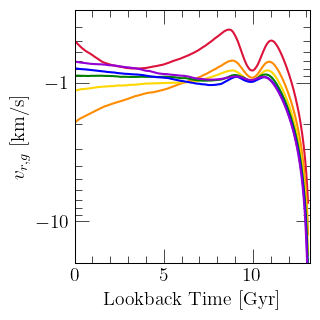

In [16]:
RADII = [3, 5, 7, 9, 11, 13]
COLORS = ["crimson", "darkorange", "gold", "green", "blue", "darkviolet"]

fig = plt.figure(figsize = (3.3, 3.3))
ax = fig.add_subplot(111)
ax.set_xlabel(r"Lookback Time [Gyr]")
ax.set_ylabel(r"$v_{r,g}$ [km/s]")
ax.set_xlim([0, 13.2])
ax.set_ylim([0.3, 20])
ax.set_yscale("log")
ax.yaxis.set_major_formatter(fsf("%g"))

def plot_velocity_evolution(ax, output, radius = 8, zone_width = 0.1, **kwargs):
    lookback, vgas = get_velocity_evolution(output, radius = radius, zone_width = zone_width)
    vgas = [-v for v in vgas]
    ax.plot(lookback, vgas, **kwargs)

for i in range(len(RADII)):
    kwargs = {
        "c": named_colors()[COLORS[i]],
        "label": r"$R = %d$ kpc" % (RADII[i])
    }
    plot_velocity_evolution(ax, output, radius = RADII[i], **kwargs)

negative_log(ax)
plt.tight_layout()
plt.show()

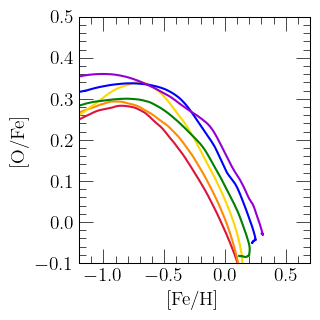

In [17]:
RADII = [3, 5, 7, 9, 11, 13]
COLORS = ["crimson", "darkorange", "gold", "green", "blue", "darkviolet"]

fig = plt.figure(figsize = (3.3, 3.3))
ax = fig.add_subplot(111)
ax.set_xlabel(r"[Fe/H]")
ax.set_ylabel(r"[O/Fe]")
ax.set_xlim([-1.2, 0.7])
ax.set_xticks([-1, -0.5, 0, 0.5])
ax.set_ylim([-0.1, 0.5])

def plot_track(ax, output, radius = 8, zone_width = 0.1, **kwargs):
    zone = int(radius / zone_width)
    zone = output.zones["zone%d" % (zone)]
    ax.plot(zone.history["[fe/h]"], zone.history["[o/fe]"], **kwargs)

for i in range(len(RADII)):
    kwargs = {
        "c": named_colors()[COLORS[i]],
        "label": r"$R = %d$ kpc" % (RADII[i])
    }
    plot_track(ax, output, radius = RADII[i], **kwargs)

plt.tight_layout()
plt.show()

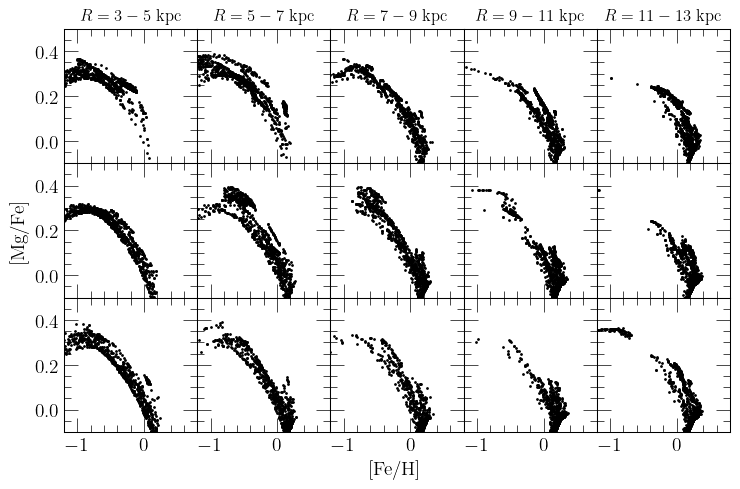

In [18]:
RADII = [[3, 5], [5, 7], [7, 9], [9, 11], [11, 13]]
ZHEIGHTS = [[1, 2], [0.5, 1], [0, 0.5]]
XLIM = [-1.2, 0.8]
YLIM = [-0.1, 0.5]
XTICKS = [-1, 0]
YTICKS = [0, 0.2, 0.4]

fig, axes = plt.subplots(nrows = len(ZHEIGHTS), ncols = len(RADII), sharex = True, sharey = True, figsize = (7.5, 5))
axes[len(ZHEIGHTS) // 2][0].set_ylabel(r"[Mg/Fe]")
axes[-1][len(RADII) // 2].set_xlabel(r"[Fe/H]")
axes[0][0].set_xlim(XLIM)
axes[0][0].set_ylim(YLIM)
axes[0][0].set_xticks(XTICKS)
axes[0][0].set_yticks(YTICKS)
for i in range(len(axes)):
    for j in range(len(axes[i])):
        if j: plt.setp(axes[i][j].get_yticklabels(), visible = False)
        if i != len(axes) - 1: plt.setp(axes[i][j].get_xticklabels(), visible = False)
        if not i: axes[i][j].set_title(r"$R = %d - %d$ kpc" % (RADII[j][0], RADII[j][1]), fontsize = 12)

def plot_subset(ax, output, rmin = 7, rmax = 9, abszmin = 0, abszmax = 0.5, zone_width = 0.1, n = 1000, **kwargs):
    zone_min = int(rmin / zone_width)
    zone_max = int(rmax / zone_width) - 1
    stars = output.stars.filter(
        "zone_final", ">=", zone_min).filter(
        "zone_final", "<=", zone_max).filter(
        "absz", ">=", abszmin).filter(
        "absz", "<=", abszmax).filter(
        "mass", ">", 1)
    stars = subsample_stars(stars, n = n)
    ax.scatter(stars["[fe/h]"], stars["[o/fe]"], **kwargs)

for i in range(len(ZHEIGHTS)):
    for j in range(len(RADII)):
        kwargs = {
            "c": named_colors()["black"],
            "s": 1,
            "rasterized": True
        }
        plot_subset(axes[i][j], output,
            rmin = RADII[j][0], rmax = RADII[j][1],
            abszmin = ZHEIGHTS[i][0], abszmax = ZHEIGHTS[i][1],
            **kwargs)

plt.tight_layout()
plt.subplots_adjust(hspace = 0, wspace = 0)
plt.show()